Yerel ve Global Dikkat Katmanları

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import visualkeras
from PIL import ImageFont
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

from tensorflow.keras.preprocessing import image_dataset_from_directory
import random
random.seed(42)

ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)
random_seed = 55
num_classes = 5
epochs = 128

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=random_seed
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

def text_callable(layer_index, layer):
    # Every other piece of text is drawn above the layer, the first one below
    above = bool(layer_index%2)

    # Get the output shape of the layer
    output_shape = [x for x in list(layer.output_shape) if x is not None]

    # If the output shape is a list of tuples, we only take the first one
    if isinstance(output_shape[0], tuple):
        output_shape = list(output_shape[0])
        output_shape = [x for x in output_shape if x is not None]

    # Variable to store text which will be drawn    
    output_shape_txt = ""

    # Create a string representation of the output shape
    for ii in range(len(output_shape)):
        output_shape_txt += str(output_shape[ii])
        if ii < len(output_shape) - 2: # Add an x between dimensions, e.g. 3x3
            output_shape_txt += "x"
        if ii == len(output_shape) - 2: # Add a newline between the last two dimensions, e.g. 3x3 \n 64
            output_shape_txt += "\n"

    # Add the name of the layer to the text, as a new line
    output_shape_txt += f"\n{layer.name}"

    # Return the text value and if it should be drawn above the layer
    return output_shape_txt, above

Found 3239 images belonging to 5 classes.
Found 810 images belonging to 5 classes.


In [3]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

class LocalAttention(Layer):
    def __init__(self, **kwargs):
        super(LocalAttention, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]), initializer='uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],), initializer='uniform', trainable=True)
        super(LocalAttention, self).build(input_shape)
    
    def call(self, inputs):
        e = tf.keras.activations.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        a = tf.keras.activations.softmax(e, axis=1)
        output = a * inputs
        return output

class GlobalAttention(Layer):
    def __init__(self, **kwargs):
        super(GlobalAttention, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]), initializer='uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],), initializer='uniform', trainable=True)
        super(GlobalAttention, self).build(input_shape)
    
    def call(self, inputs):
        e = tf.keras.activations.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        a = tf.keras.activations.softmax(e, axis=1)
        output = tf.keras.backend.sum(a * inputs, axis=1)
        return output


In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Reshape, multiply, BatchNormalization
from tensorflow.keras import backend as K

# Squeeze-and-Excitation bloğu
def squeeze_excite_block(input, ratio=16):
    init = input
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = GlobalAveragePooling2D()(init)
    se = Reshape(se_shape)(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    x = multiply([init, se])
    return x

input_layer = Input(shape=(224, 224, 3))

# 1. Evrişim Katmanı
x = Conv2D(32, (3, 3), activation='relu')(input_layer)
x = BatchNormalization()(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)
x = LocalAttention()(x)

# 2. Evrişim Katmanı
x = Conv2D(64, (3, 3), activation='relu')(x)
x = BatchNormalization()(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)
x = LocalAttention()(x)

# 3. Evrişim Katmanı
x = Conv2D(128, (3, 3), activation='relu')(x)
x = BatchNormalization()(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)
x = LocalAttention()(x)

# 4. Evrişim Katmanı
x = Conv2D(256, (3, 3), activation='relu')(x)
x = BatchNormalization()(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)
x = LocalAttention()(x)

# 5. Evrişim Katmanı
x = Conv2D(512, (3, 3), activation='relu')(x)
x = BatchNormalization()(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)
x = LocalAttention()(x)

# Global Dikkat Katmanı
x = GlobalAttention()(x)

# Düzleştirme katmanı
x = Flatten()(x)

# Tam bağlantılı katmanlar
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Çıkış katmanı (örneğin, 10 sınıflı bir sınıflandırma için)
output_layer = Dense(num_classes, activation='softmax')(x)

# Modeli oluşturma
model = Model(inputs=input_layer, outputs=output_layer)

# Modeli derleme
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Modelin özetini yazdırma
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 222, 222, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 222, 222, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                             

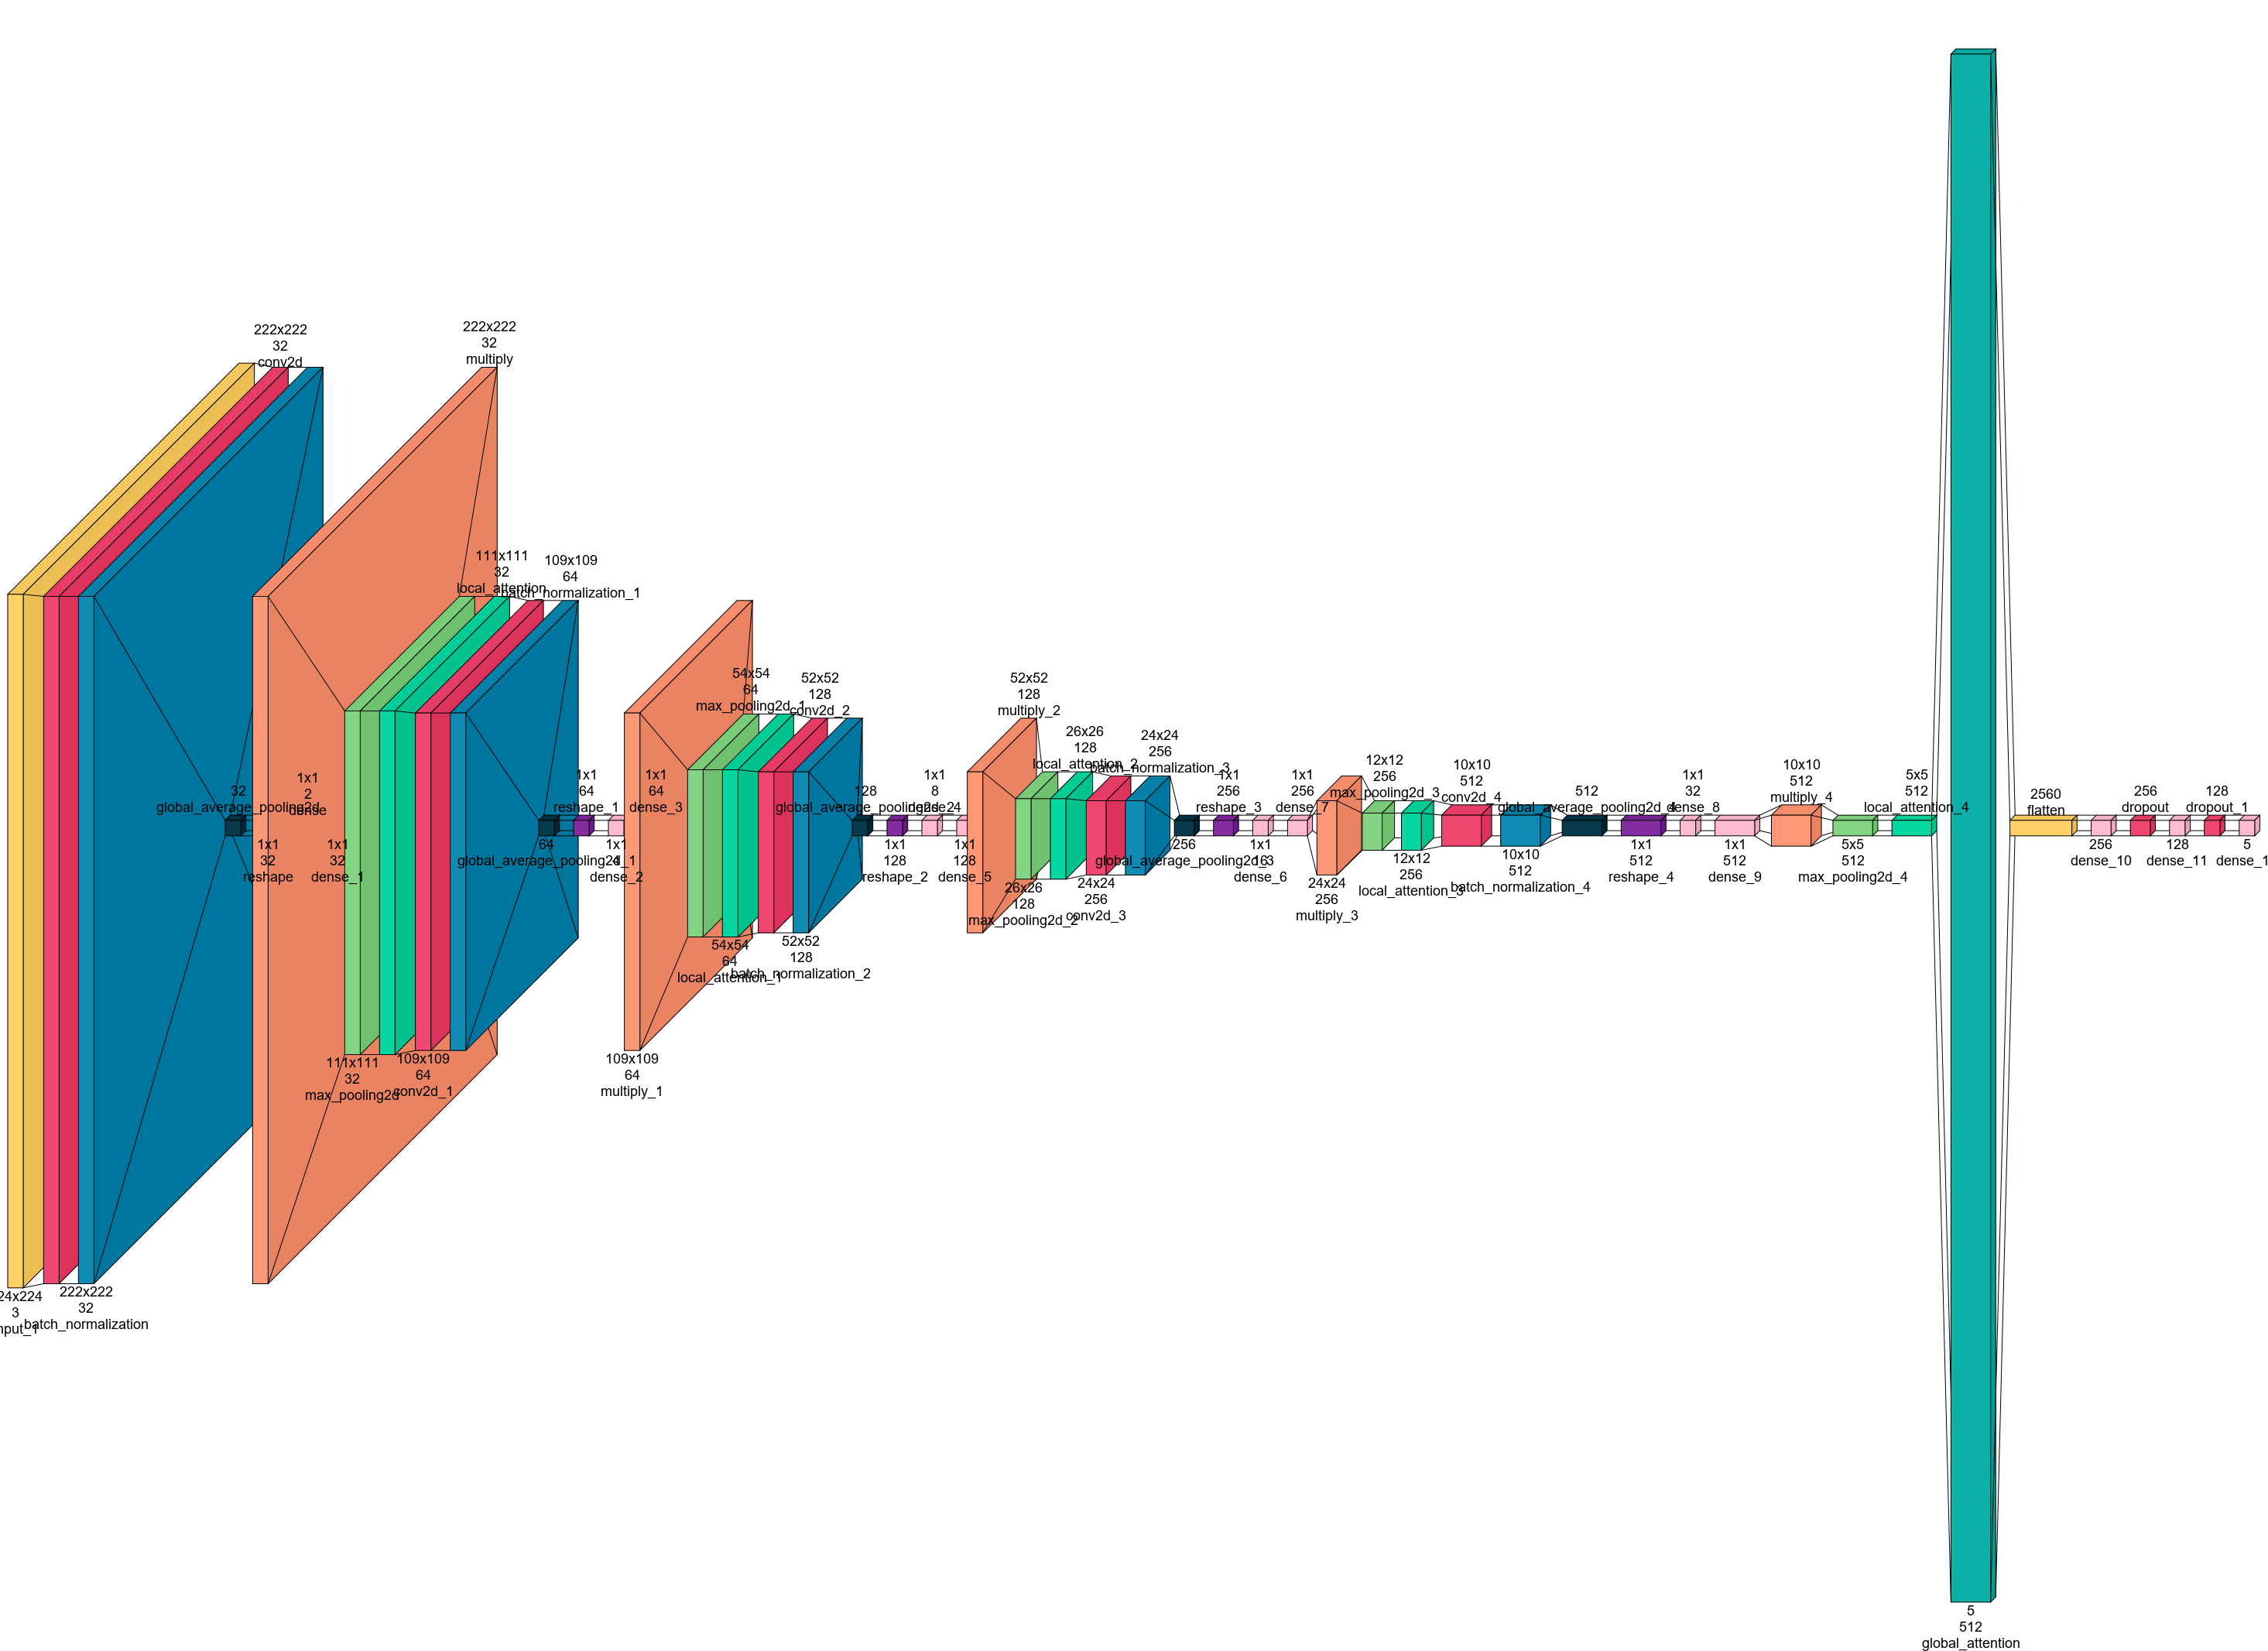

In [5]:
class CustomLayer(Layer):
    def __init__(self, layer, scale_xy=0.5, scale_z=0.5, *args, **kwargs):
        super().__init__(layer, *args, **kwargs)
        self.scale_xy = scale_xy
        self.scale_z = scale_z

    def __call__(self, image):
        image = super().__call__(image)
        return image.resize((int(image.width * self.scale_xy), int(image.height * self.scale_z)))
     
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 18)  # using comic sans is strictly prohibited!
visualkeras.layered_view(model, 
                            draw_volume=True,
                            legend=False, 
                            font=font, 
                            show_dimension=True,
                            scale_xy=4, 
                            scale_z=0.1,
                            max_z=80,
                            spacing=25, 
                            text_callable=text_callable,  # Özelleştirilmiş metin fonksiyonunu ekler,
                            
                         )

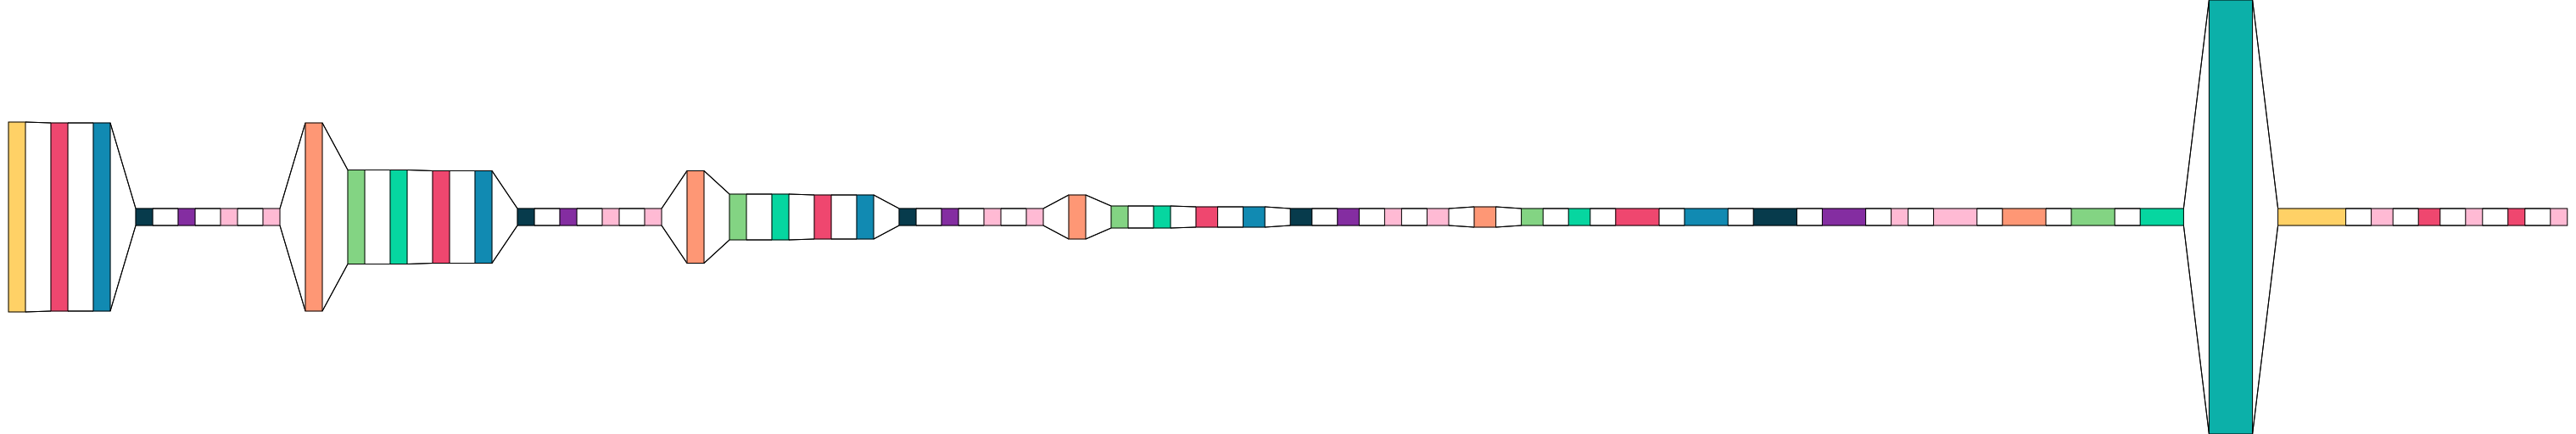

In [6]:
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)  # using comic sans is strictly prohibited!
visualkeras.layered_view(model, 
                            draw_volume=False,
                            legend=False, 
                            font=font, 
                            show_dimension=False,
                            scale_xy=1, 
                            scale_z=.1,
                            max_z=80,
                            spacing=30, 
                           #  text_callable=text_callable  # Özelleştirilmiş metin fonksiyonunu ekler
                         )

In [8]:
# Modeli eğitmek için kod
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Metric to monitor for improvement
    patience=3,  # Number of epochs to wait before stopping
    restore_best_weights=True  # Restore the best model weights
)

# Train the model
callbacks=[early_stopping]

history= model.fit(
    train_gen,
    epochs=epochs,
    batch_size=batch_size, # Number
    validation_data=valid_gen,
    callbacks=callbacks
)

Epoch 1/128
810/810 [==============================] - 60s 73ms/step - loss: 0.2190 - accuracy: 0.9312 - val_loss: 0.2676 - val_accuracy: 0.9148
Epoch 2/128
810/810 [==============================] - 60s 74ms/step - loss: 0.2037 - accuracy: 0.9324 - val_loss: 0.2632 - val_accuracy: 0.9160
Epoch 3/128
810/810 [==============================] - 60s 74ms/step - loss: 0.1900 - accuracy: 0.9312 - val_loss: 0.2478 - val_accuracy: 0.9160
Epoch 4/128
810/810 [==============================] - 58s 72ms/step - loss: 0.1846 - accuracy: 0.9312 - val_loss: 0.3471 - val_accuracy: 0.9037
Epoch 5/128
810/810 [==============================] - 57s 71ms/step - loss: 0.1596 - accuracy: 0.9441 - val_loss: 0.2520 - val_accuracy: 0.9235
Epoch 6/128
810/810 [==============================] - 57s 70ms/step - loss: 0.1532 - accuracy: 0.9447 - val_loss: 0.3217 - val_accuracy: 0.8975


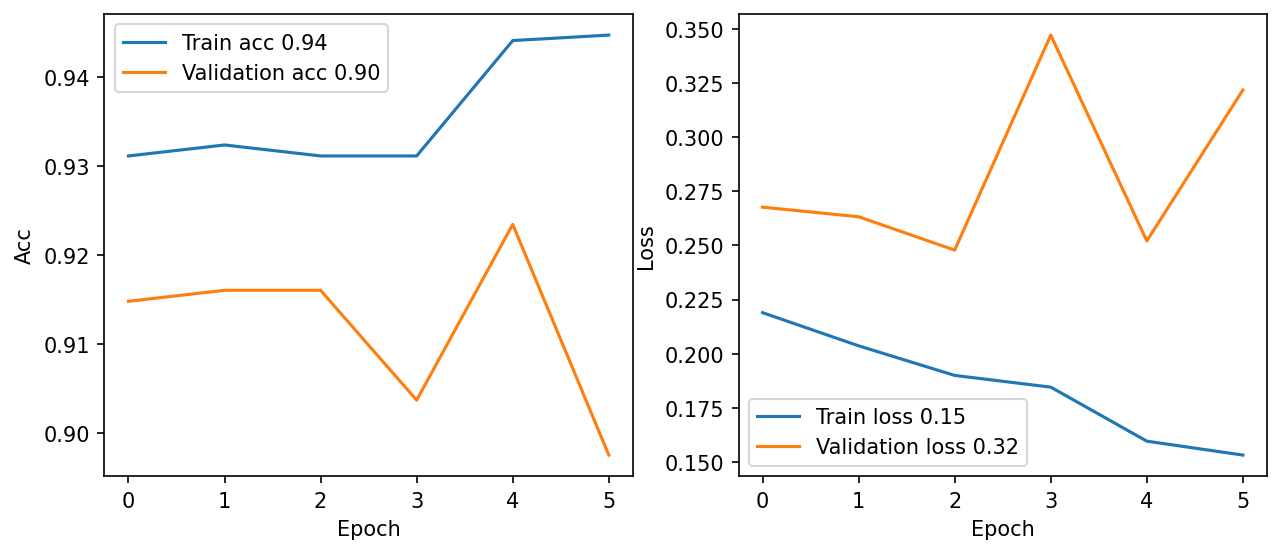

In [9]:
from helper import Helper
_helper = Helper()
_helper.plot_train_and_val_curves(history)

203/203 [==============================] - 7s 31ms/step


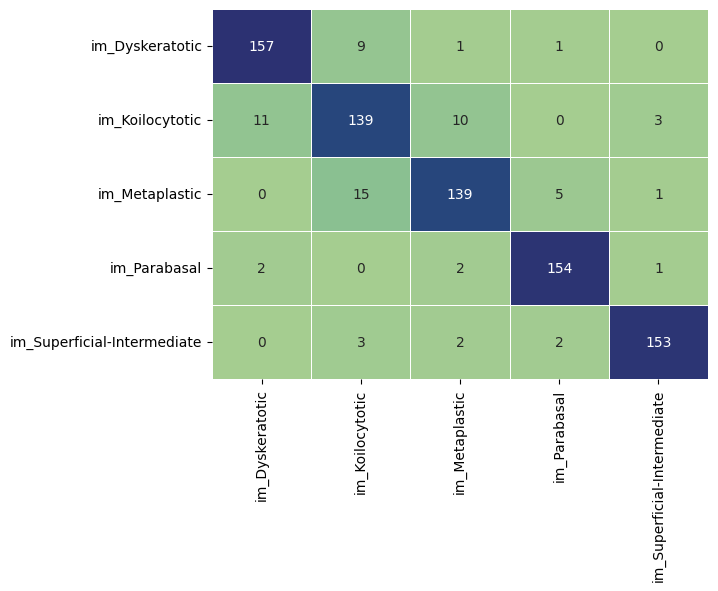

In [10]:
_helper.plot_confusion_matrix(model, valid_gen)

203/203 [==============================] - 6s 30ms/step


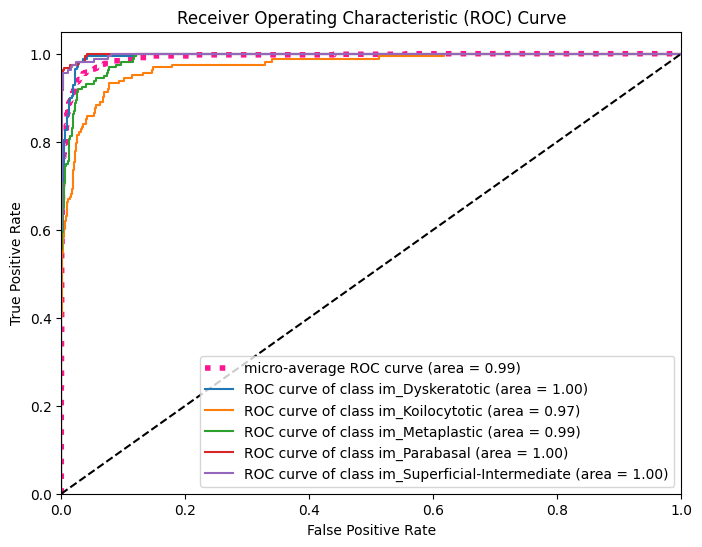

In [11]:
_helper.plot_roc_curve(model, valid_gen)

In [ ]:
import pickle
model.save("model3.h5")
# history değişkenini pickle ile kaydetme
with open('model3.pkl', 'wb') as file:
    pickle.dump(history.history, file)

In [12]:
from confusion import Confusion
cm = _helper.get_confusion_matrix(model, valid_gen)
Confusion.getValues(cm)

203/203 [==============================] - 6s 28ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       168
           1       0.84      0.85      0.84       163
           2       0.90      0.87      0.89       160
           3       0.95      0.97      0.96       159
           4       0.97      0.96      0.96       160

    accuracy                           0.92       810
   macro avg       0.92      0.92      0.92       810
weighted avg       0.92      0.92      0.92       810

Confusion Matrix:
[[157   9   1   1   0]
 [ 11 139  10   0   3]
 [  0  15 139   5   1]
 [  2   0   2 154   1]
 [  0   3   2   2 153]]


,Value
Accuracy,0.9160
Error,0.0840
Sensitivity,0.9162
Specificity,0.9790
Precision,0.9165
FalsePositiveRate,0.0210
F1_score,0.9162
MatthewsCorrelationCoefficient,0.8953


In [ ]:
import cv2

# Grad-CAM fonksiyonu
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Görüntüyü ve Grad-CAM haritasını birleştirme fonksiyonu
def display_gradcam(image, heatmap, alpha=0.4):
    img = image.copy()
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    output = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return output

# Test setinden bir örnek resim seçme
for i in range(len(valid_gen)):
    x, y = valid_gen[i]
    # Sadece ilk görüntü üzerinde çalışmak için döngüyü kır
    if i == 0:
        break

# Grad-CAM ısı haritasını elde etme
last_conv_layer_name = "conv2d_14"  # Değiştirilebilir: Modelinizin son evrişim katmanının adı
heatmap = get_gradcam_heatmap(model, x, last_conv_layer_name)

# Orijinal görüntüyü al ve normalleştir
original_img = x[0]
original_img = np.uint8(255 * original_img)

# Grad-CAM ısı haritası ile görüntüyü birleştirme
gradcam_img = display_gradcam(original_img, heatmap)

# Görüntüleri gösterme
plt.figure(figsize=(15, 8))

# Orijinal görüntü
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Orijinal Görüntü")

# Grad-CAM ile görselleştirme
plt.subplot(1, 2, 2)
plt.imshow(gradcam_img)
plt.title("Grad-CAM ile Görselleştirme")

plt.show()

In [ ]:
# Grad-CAM fonksiyonu
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds

# Görüntüyü ve Grad-CAM haritasını birleştirme fonksiyonu
def display_gradcam(image, heatmap, alpha=0.4):
    img = image.copy()
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    output = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return output

# Test setinden bir dizi resim seçme ve görselleştirme
last_conv_layer_name = "conv2d_9"  # Modelinizin son evrişim katmanının adı
num_images = 5  # Görselleştirilmek istenen görüntü sayısı (her satırda 5 görüntü olacak şekilde)

plt.figure(figsize=(20, 8))

for i in range(num_images):
    x, y = valid_gen[i]
    heatmap, preds = get_gradcam_heatmap(model, x, last_conv_layer_name)
    original_img = x[0]
    original_img = np.uint8(255 * original_img)
    gradcam_img = display_gradcam(original_img, heatmap)

    # Orijinal görüntü
    plt.subplot(2, num_images, i + 1)
    plt.imshow(original_img)
    plt.axis('off')
    # plt.title(f"Orijinal - P={np.max(preds):.5f}")

    # Grad-CAM görüntüsü
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(gradcam_img)
    plt.axis('off')
    # plt.title(f"Grad-CAM - Sınıf {np.argmax(preds)}")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os
import matplotlib.pyplot as plt



# Derin özellikleri çıkarmak için ara katmanı belirleme
layer_name = 'conv2d_9'

# Ara katmandan özellikleri çıkartacak yeni model oluşturma
intermediate_layer_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)

# Özellikleri çıkartmak için veri kümesinden bir örnek seçme
for x, y in valid_gen:
    break  # İlk batch'ten verileri al

# Özellikleri çıkartma
intermediate_output = intermediate_layer_model.predict(x)

# Çıkarılan özelliklerin boyutlarını yazdırma
print("Ara katmandan çıkarılan özelliklerin boyutları:", intermediate_output.shape)

# İlk resmin tüm kanallarını görselleştirme
num_channels = intermediate_output.shape[-1]
fig, axes = plt.subplots(8, 8, figsize=(20, 20))  # 8x8 grid şeklinde görselleştir
for i in range(64):  # İlk 64 kanalı görselleştirme
    ax = axes[i // 8, i % 8]
    ax.imshow(intermediate_output[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.show()
